# La Antártida occidental se derritió antes — y dejó su firma en el polvo

¿Qué pasa cuando la Antártida pierde su escudo de hielo flotante más grande? Por primera vez tenemos una pista química directa: el polvo atrapado en el hielo cambió de fuente hace 125.000 años.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Diminished Ross Ice Shelf and West Antarctic Ice Sheet during Last Interglacial warming  
**Journal:** Nature Geoscience (2026)  
**DOI:** [10.1038/s41561-026-01988-1](https://doi.org/10.1038/s41561-026-01988-1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-26-ross-ice-shelf-mis-5e/notebook.ipynb)

**Video corto:** [Ver en YouTube](https://youtube.com/shorts/A7lJOVGykP0)

## El núcleo, el polvo y la pregunta

El núcleo de hielo ALHIC1903 lo perforó un equipo en Allan Hills, un sector del este de la Antártida donde el viento expone hielo muy antiguo en la superficie — más viejo que cualquier otro núcleo profundo conocido.

Cubre dos mundos climáticos muy distintos:

- **MIS 6** (~140.000 años atrás): glacial intenso, frío y seco.
- **MIS 5e** (~125.000 años atrás): el último interglacial, **2-3 °C más cálido que hoy** y con un mar 5-10 metros más alto.

La pregunta del paper: si la Antártida occidental perdió ese exceso de hielo durante MIS 5e, ¿queda alguna huella química de eso? Su apuesta: el polvo. Cuando el manto de hielo se reorganiza, las rutas del viento cambian, y eso debería notarse en la firma isotópica del polvo atrapado en el núcleo.

Vamos a abrir los datos isotópicos directos del paper y mirar si esa huella existe.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_TERMINATION_II_KA = 129.0   # frontera MIS 6 (glacial) / MIS 5e (interglacial)
UMBRAL_FIRMA_ANTARTICA = 0.0       # eps_nd > 0 → fuente volcánica antártica local
COLOR_MIS5E = "#D97706"            # interglacial cálido (ámbar)
COLOR_MIS6 = "#2563EB"             # glacial frío (azul CaM)
COLOR_ANTARTIDA = "#059669"        # fuentes locales antárticas (esmeralda)
COLOR_SUDAMERICA = "#7C3AED"       # fuente dominante MIS 6 (violeta)
COLOR_REMOTA = "#BBBBBB"           # fuentes excluidas (gris)
FUENTE = (
    "Fuente: Datos del paper Nature Geoscience (DOI: 10.1038/s41561-026-01988-1) | "
    "Núcleo ALHIC1903, Allan Hills, Antártida"
)

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main"
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f"{BASE}/cam.mplstyle", style_file)
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
DATA_DIR = "datos" if os.path.isdir("datos") else "/home/jupyter/datos"
srnd = pd.read_csv(f"{DATA_DIR}/alhic1903_srnd.csv")
dust = pd.read_csv(f"{DATA_DIR}/alhic1903_dust_conc.csv")
dd   = pd.read_csv(f"{DATA_DIR}/alhic1903_dD.csv")
psa  = pd.read_csv(f"{DATA_DIR}/psa_database.csv")

srnd["mis"] = np.where(srnd["age_ka"] < UMBRAL_TERMINATION_II_KA, "MIS 5e", "MIS 6")
dust["mis"] = np.where(dust["age_ka"] < UMBRAL_TERMINATION_II_KA, "MIS 5e", "MIS 6")
dd["mis"]   = np.where(dd["age_ka"]   < UMBRAL_TERMINATION_II_KA, "MIS 5e", "MIS 6")

print(f"Sr/Nd: {len(srnd)} muestras del núcleo ALHIC1903")
print(f"  con εNd válido: {srnd['epsilon_nd'].notna().sum()}")
print(f"  con 87Sr/86Sr válido: {srnd['sr87_sr86'].notna().sum()}")
print(f"Dust: {len(dust)} mediciones de concentración (Coulter Counter)")
print(f"δD:   {len(dd)} mediciones de deuterio (proxy de temperatura)")
print(f"PSA:  {len(psa)} muestras de referencia de 11 regiones del planeta")
print()
print("Rango de edad del núcleo: "
      f"{srnd['age_ka'].min():.1f} - {srnd['age_ka'].max():.1f} ka")
print(f"Frontera glacial/interglacial usada: {UMBRAL_TERMINATION_II_KA} ka (Termination II)")

Sr/Nd: 22 muestras del núcleo ALHIC1903
  con εNd válido: 19
  con 87Sr/86Sr válido: 21
Dust: 41 mediciones de concentración (Coulter Counter)
δD:   63 mediciones de deuterio (proxy de temperatura)
PSA:  381 muestras de referencia de 11 regiones del planeta

Rango de edad del núcleo: 119.3 - 146.8 ka
Frontera glacial/interglacial usada: 129.0 ka (Termination II)


## Aquí está la huella.

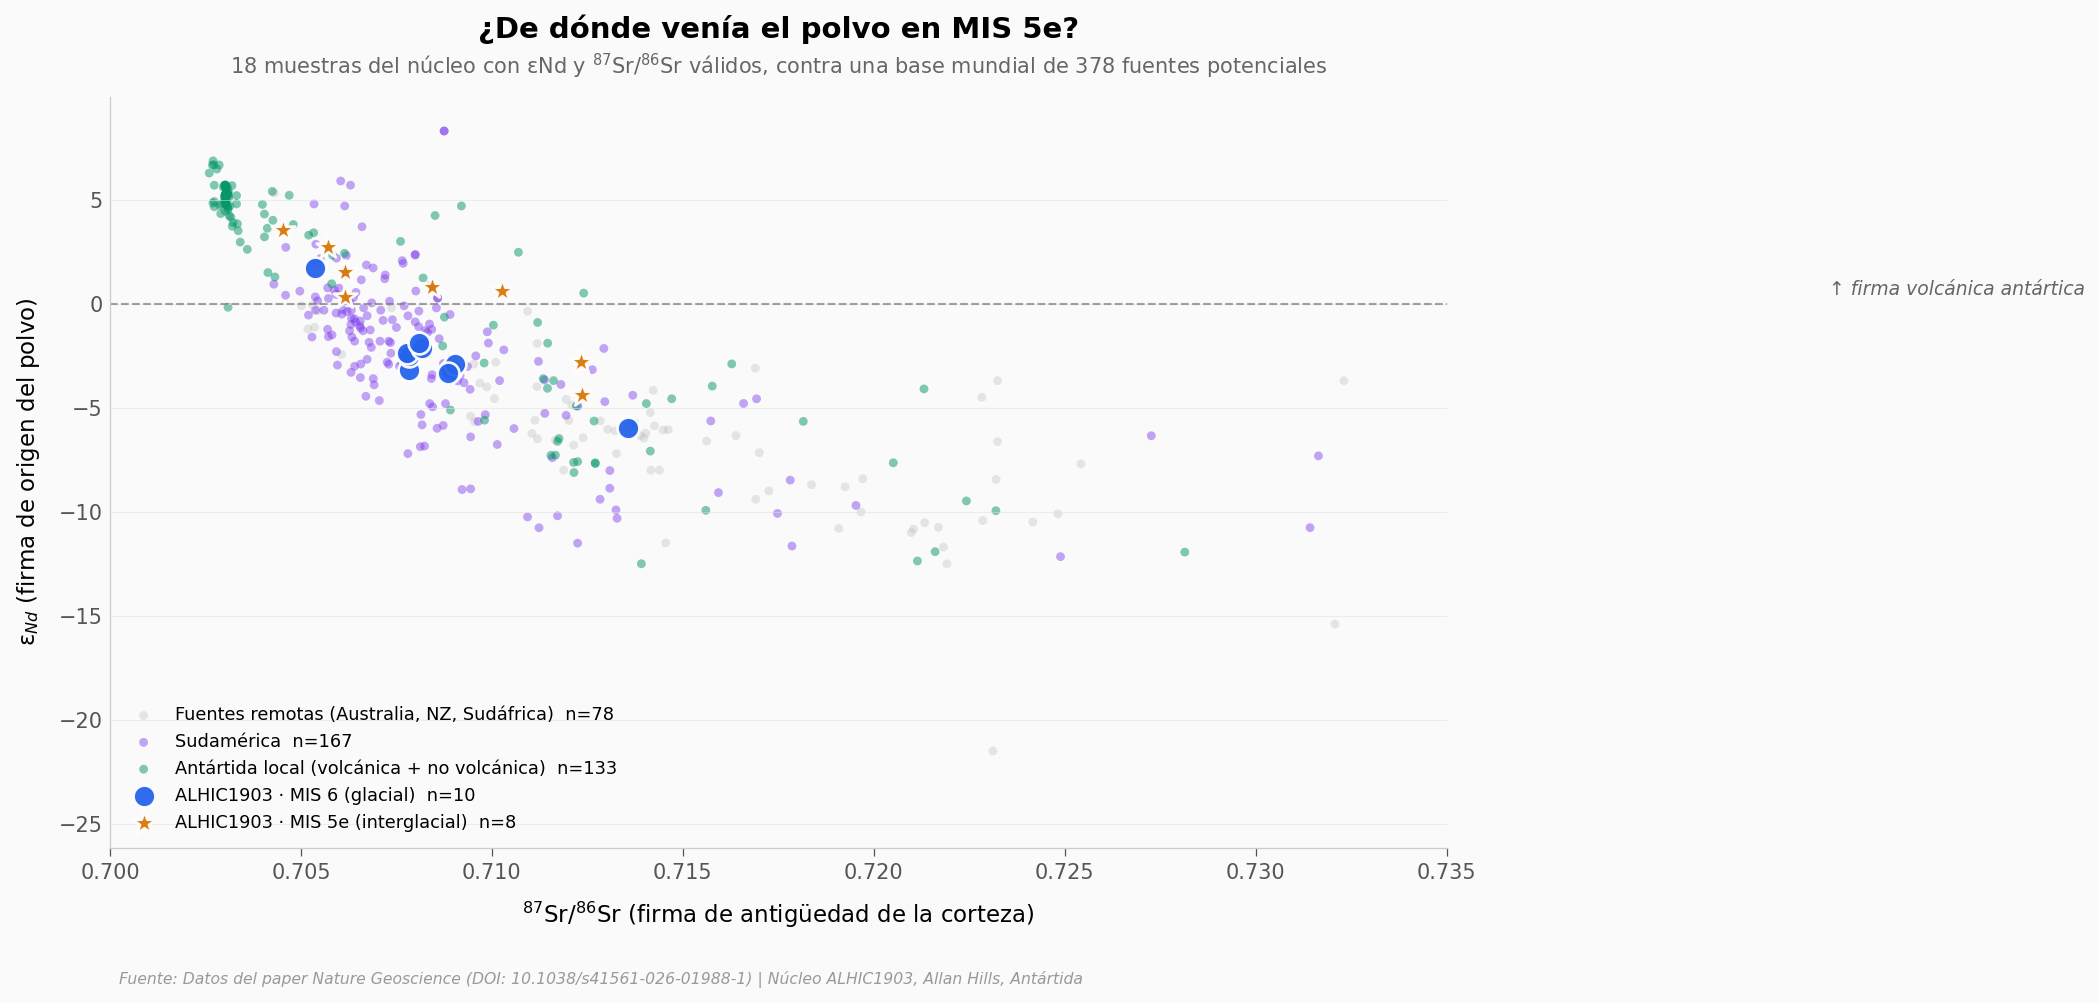

In [2]:
# ══════════════════════════════════════════════════════════════
# GRÁFICA HERO: plano εNd vs 87Sr/86Sr — el "ADN" del polvo
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11.5, 6.5))

# Clasificar las PSAs en 3 grupos narrativos
psa = psa.dropna(subset=["epsilon_nd", "sr87_sr86"])
psa_sudamerica = psa[psa["potential_source_area"] == "South America"]
psa_antarctida = psa[psa["potential_source_area"].isin(
    ["Erebus", "Marie Byrd Land", "McMurdo Sound",
     "Dry Valleys", "Northern Victoria Land", "Southern Victoria Land"]
)]
psa_remota = psa[~psa["potential_source_area"].isin(
    list(psa_sudamerica["potential_source_area"].unique()) +
    list(psa_antarctida["potential_source_area"].unique())
)]

# Nube de fondo: fuentes potenciales
ax.scatter(psa_remota["sr87_sr86"], psa_remota["epsilon_nd"],
           color=COLOR_REMOTA, s=18, alpha=0.35, edgecolors="none",
           label=f"Fuentes remotas (Australia, NZ, Sudáfrica)  n={len(psa_remota)}")
ax.scatter(psa_sudamerica["sr87_sr86"], psa_sudamerica["epsilon_nd"],
           color=COLOR_SUDAMERICA, s=18, alpha=0.45, edgecolors="none",
           label=f"Sudamérica  n={len(psa_sudamerica)}")
ax.scatter(psa_antarctida["sr87_sr86"], psa_antarctida["epsilon_nd"],
           color=COLOR_ANTARTIDA, s=18, alpha=0.50, edgecolors="none",
           label=f"Antártida local (volcánica + no volcánica)  n={len(psa_antarctida)}")

# Nuestras 22 muestras del núcleo, encima
alhic = srnd.dropna(subset=["epsilon_nd", "sr87_sr86"])
mis5 = alhic[alhic["mis"] == "MIS 5e"]
mis6 = alhic[alhic["mis"] == "MIS 6"]

ax.scatter(mis6["sr87_sr86"], mis6["epsilon_nd"],
           color=COLOR_MIS6, s=110, alpha=0.95,
           edgecolors="white", linewidths=1.3, zorder=6,
           marker="o", label=f"ALHIC1903 · MIS 6 (glacial)  n={len(mis6)}")
ax.scatter(mis5["sr87_sr86"], mis5["epsilon_nd"],
           color=COLOR_MIS5E, s=140, alpha=0.95,
           edgecolors="white", linewidths=1.3, zorder=7,
           marker="*", label=f"ALHIC1903 · MIS 5e (interglacial)  n={len(mis5)}")

# Línea horizontal en eps_nd = 0 (frontera firma volcánica antártica)
ax.axhline(y=UMBRAL_FIRMA_ANTARTICA, color="#666666",
           linewidth=1.0, linestyle="--", alpha=0.6, zorder=2)
ax.text(0.745, 0.4, "↑ firma volcánica antártica",
        fontsize=9, color="#666666", style="italic")

ax.set_xlabel("$^{87}$Sr/$^{86}$Sr (firma de antigüedad de la corteza)", fontsize=11)
ax.set_ylabel("ε$_{Nd}$ (firma de origen del polvo)", fontsize=11)
ax.set_title("¿De dónde venía el polvo en MIS 5e?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "18 muestras del núcleo con εNd y $^{87}$Sr/$^{86}$Sr válidos, contra una base mundial de 378 fuentes potenciales",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.legend(fontsize=8.5, loc="lower left", framealpha=0.92, ncol=1)

ax.set_xlim(0.700, 0.735)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/hero_epsnd_vs_sr.png", dpi=200, bbox_inches="tight")
plt.show()

### Lo que cambia entre los dos mundos

Casi todas las muestras MIS 6 (puntos azules) se agrupan abajo, dentro del rango sudamericano. Esa fuente — los desiertos patagónicos — es la que esperamos para un glacial frío y seco: vientos del oeste fuertes traen polvo desde Sudamérica hasta el Pacífico Sur y la Antártida.

Las muestras MIS 5e (estrellas ámbar) se reparten distinto. Varias saltan por encima de la línea ε$_{Nd}$ = 0, dentro del rango antártico local. El paper se apoya en este reparto: en MIS 5e aparece — o se vuelve dominante — una fuente de polvo cercana, volcánica, del sector del rift antártico occidental. Y eso solo se explica si el viaje del polvo se reorganizó.

Los autores lo dicen con cautela — *suggests* (sugiere, no demuestra). Es un cambio de **fuente dominante**, no una diferencia estadísticamente significativa de medias (volvemos a esto al final).

## El cambio en el tiempo

Si vemos cada muestra en su edad real, el patrón se ordena en una secuencia: la mayor parte de la transición ocurre alrededor de la Terminación II (~129 ka), cuando el clima saltó de glacial a interglacial.

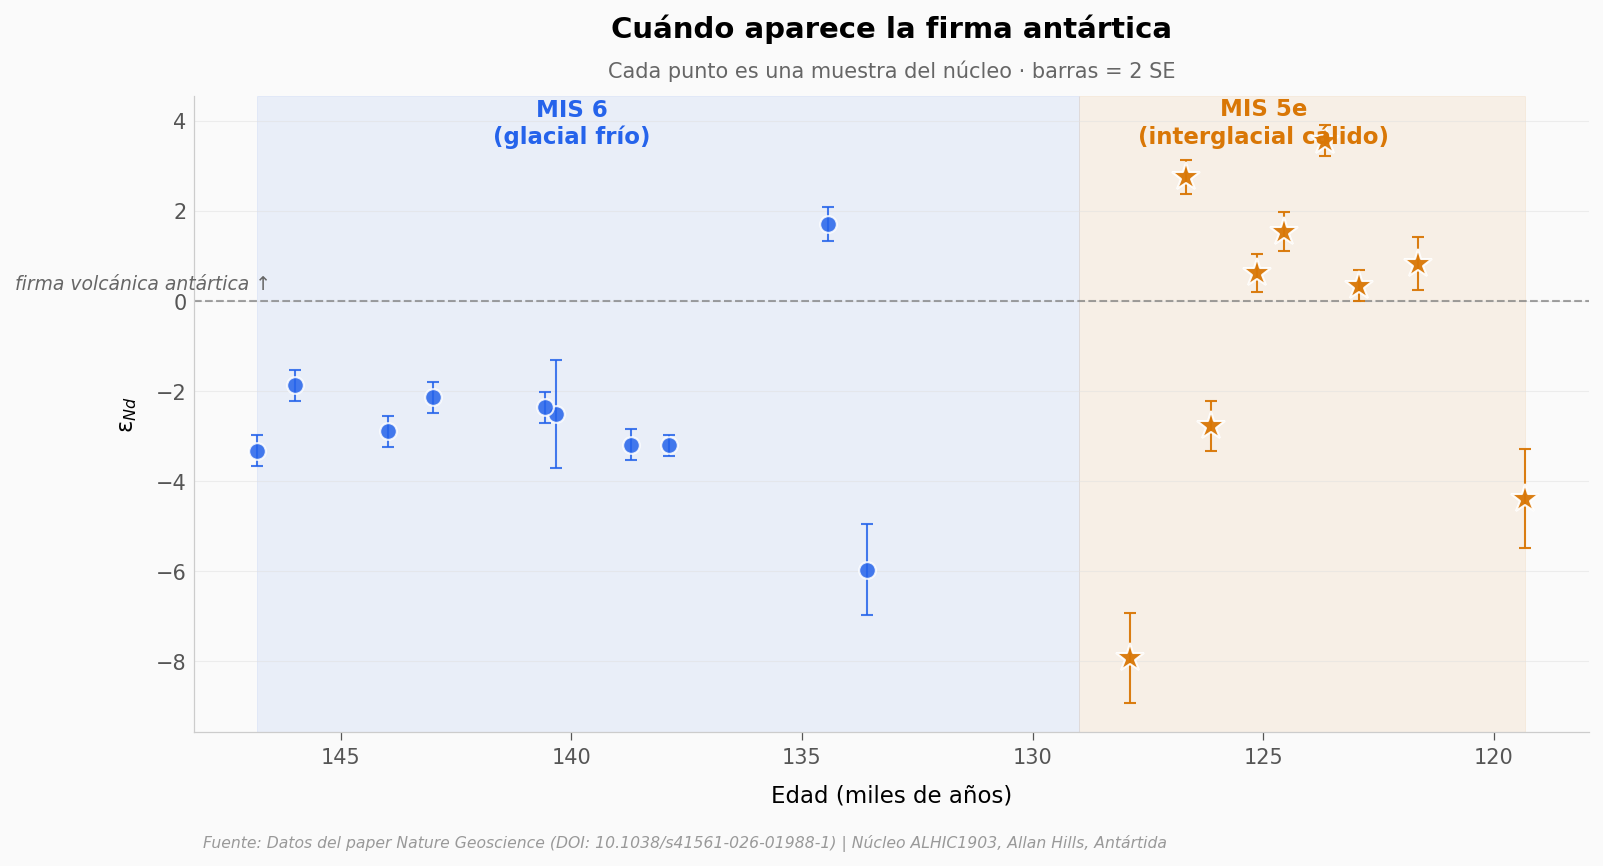

Muestras con firma antártica (ε_Nd > 0):
  MIS 5e: 6 de 9 (67%)
  MIS 6:  1 de 10 (10%)


In [3]:
# ══════════════════════════════════════════════════════════════
# εNd a lo largo del tiempo
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5.5))

alhic_t = srnd.dropna(subset=["epsilon_nd"]).sort_values("age_ka")

# Sombreado vertical para los dos periodos
ax.axvspan(UMBRAL_TERMINATION_II_KA, alhic_t["age_ka"].max(),
           color=COLOR_MIS6, alpha=0.08, zorder=0)
ax.axvspan(alhic_t["age_ka"].min(), UMBRAL_TERMINATION_II_KA,
           color=COLOR_MIS5E, alpha=0.08, zorder=0)

# Línea horizontal en eps_nd = 0
ax.axhline(y=0, color="#666666", linewidth=1.0, linestyle="--", alpha=0.6)

# Puntos con barras de error 2 SE
mis5_t = alhic_t[alhic_t["mis"] == "MIS 5e"]
mis6_t = alhic_t[alhic_t["mis"] == "MIS 6"]
ax.errorbar(mis6_t["age_ka"], mis6_t["epsilon_nd"],
            yerr=mis6_t["eps_nd_err_2se"], fmt="o",
            color=COLOR_MIS6, markersize=8, capsize=3, capthick=1,
            elinewidth=1, ecolor=COLOR_MIS6, alpha=0.85,
            markeredgecolor="white", markeredgewidth=1)
ax.errorbar(mis5_t["age_ka"], mis5_t["epsilon_nd"],
            yerr=mis5_t["eps_nd_err_2se"], fmt="*",
            color=COLOR_MIS5E, markersize=14, capsize=3, capthick=1,
            elinewidth=1, ecolor=COLOR_MIS5E, alpha=0.95,
            markeredgecolor="white", markeredgewidth=1)

# Inline labels
ax.text(125, 3.5, "MIS 5e\n(interglacial cálido)",
        fontsize=11, color=COLOR_MIS5E, fontweight="bold", ha="center")
ax.text(140, 3.5, "MIS 6\n(glacial frío)",
        fontsize=11, color=COLOR_MIS6, fontweight="bold", ha="center")
ax.text(alhic_t["age_ka"].max() - 0.3, 0.25,
        "firma volcánica antártica ↑", fontsize=9, color="#666666",
        style="italic", ha="right")

ax.set_xlabel("Edad (miles de años)", fontsize=11)
ax.set_ylabel("ε$_{Nd}$", fontsize=11)
ax.set_title("Cuándo aparece la firma antártica",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Cada punto es una muestra del núcleo · barras = 2 SE",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.invert_xaxis()  # pasado a la derecha

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/serie_temporal_epsnd.png", dpi=200, bbox_inches="tight")
plt.show()

# Resumen para "narrar" abajo
n_mis5_volcanica = (mis5_t["epsilon_nd"] > UMBRAL_FIRMA_ANTARTICA).sum()
n_mis6_volcanica = (mis6_t["epsilon_nd"] > UMBRAL_FIRMA_ANTARTICA).sum()
print(f"Muestras con firma antártica (ε_Nd > 0):")
print(f"  MIS 5e: {n_mis5_volcanica} de {len(mis5_t)} "
      f"({100*n_mis5_volcanica/len(mis5_t):.0f}%)")
print(f"  MIS 6:  {n_mis6_volcanica} de {len(mis6_t)} "
      f"({100*n_mis6_volcanica/len(mis6_t):.0f}%)")

## El polvo y la temperatura en paralelo

Para anclar el cambio en algo más, miremos el contexto climático: cuánto polvo había en cada época y qué nos dice el δD (deuterio) sobre la temperatura. Vienen del mismo núcleo, mismo rango de edad.

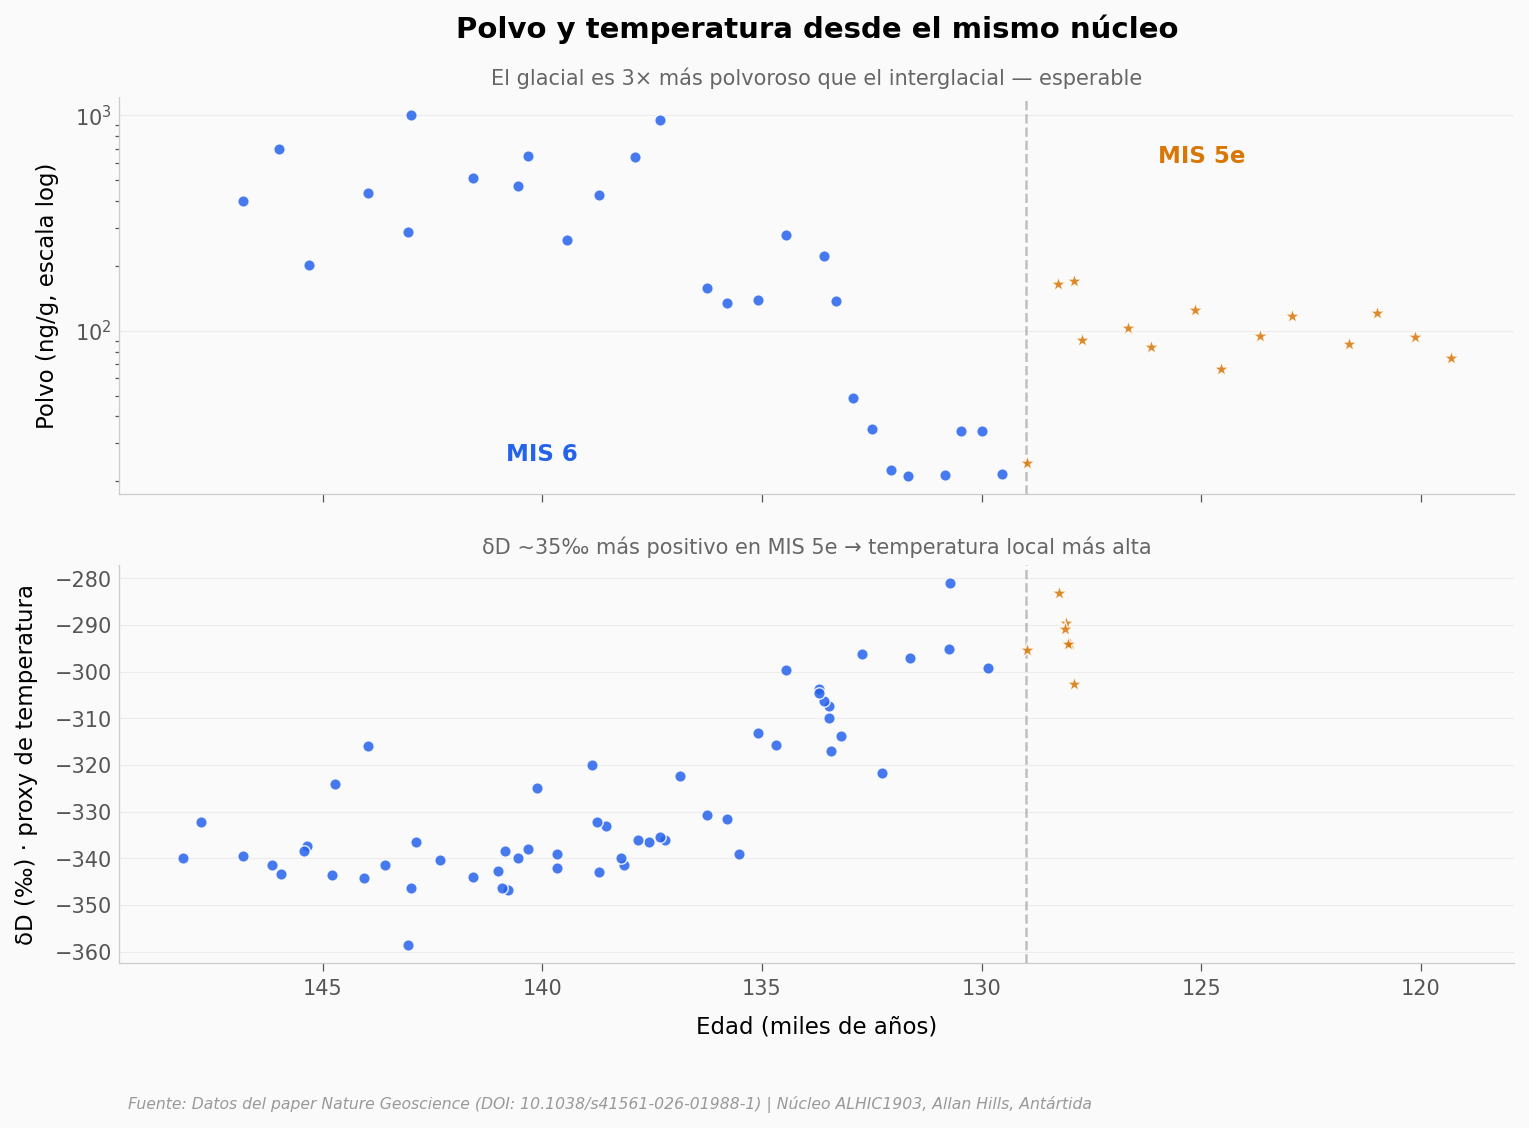

Polvo medio MIS 6:  306 ng/g (máximo 1009 ng/g)
Polvo medio MIS 5e: 101 ng/g
  Razón MIS 6 / MIS 5e: 3.0×
δD medio MIS 6:  -328.3 ‰
δD medio MIS 5e: -292.8 ‰
  Diferencia: 35.5 ‰


In [4]:
# ══════════════════════════════════════════════════════════════
# Dust + δD a lo largo del tiempo
# ══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                                gridspec_kw={"hspace": 0.18})

# Panel superior: dust concentration (escala log)
for label, color, marker, size in [("MIS 6", COLOR_MIS6, "o", 30),
                                    ("MIS 5e", COLOR_MIS5E, "*", 60)]:
    d = dust[dust["mis"] == label].sort_values("age_ka")
    ax1.scatter(d["age_ka"], d["dust_conc_ng_g"],
                color=color, s=size, alpha=0.85,
                edgecolors="white", linewidths=0.7, marker=marker, zorder=5)
ax1.set_yscale("log")
ax1.set_ylabel("Polvo (ng/g, escala log)", fontsize=11)
ax1.axvline(x=UMBRAL_TERMINATION_II_KA, color="#999999",
            linewidth=1.2, linestyle="--", alpha=0.6)
ax1.text(0.5, 1.03,
         "El glacial es 3× más polvoroso que el interglacial — esperable",
         transform=ax1.transAxes, fontsize=10, color="#666666", ha="center")
ax1.set_title("Polvo y temperatura desde el mismo núcleo",
              fontsize=14, fontweight="bold", pad=28)

# Inline labels en panel 1
ax1.text(125, 600, "MIS 5e", fontsize=11, color=COLOR_MIS5E,
         fontweight="bold", ha="center")
ax1.text(140, 25, "MIS 6", fontsize=11, color=COLOR_MIS6,
         fontweight="bold", ha="center")

# Panel inferior: δD
for label, color, marker, size in [("MIS 6", COLOR_MIS6, "o", 30),
                                    ("MIS 5e", COLOR_MIS5E, "*", 60)]:
    d = dd[dd["mis"] == label].sort_values("age_ka")
    ax2.scatter(d["age_ka"], d["dD_per_mil"],
                color=color, s=size, alpha=0.85,
                edgecolors="white", linewidths=0.7, marker=marker, zorder=5)
ax2.axvline(x=UMBRAL_TERMINATION_II_KA, color="#999999",
            linewidth=1.2, linestyle="--", alpha=0.6)
ax2.set_xlabel("Edad (miles de años)", fontsize=11)
ax2.set_ylabel("δD (‰) · proxy de temperatura", fontsize=11)
ax2.invert_xaxis()
ax2.text(0.5, 1.03,
         "δD ~35‰ más positivo en MIS 5e → temperatura local más alta",
         transform=ax2.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/serie_dust_dD.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Polvo medio MIS 6:  {dust[dust['mis']=='MIS 6']['dust_conc_ng_g'].mean():.0f} ng/g "
      f"(máximo {dust['dust_conc_ng_g'].max():.0f} ng/g)")
print(f"Polvo medio MIS 5e: {dust[dust['mis']=='MIS 5e']['dust_conc_ng_g'].mean():.0f} ng/g")
print(f"  Razón MIS 6 / MIS 5e: "
      f"{dust[dust['mis']=='MIS 6']['dust_conc_ng_g'].mean() / dust[dust['mis']=='MIS 5e']['dust_conc_ng_g'].mean():.1f}×")
print(f"δD medio MIS 6:  {dd[dd['mis']=='MIS 6']['dD_per_mil'].mean():.1f} ‰")
print(f"δD medio MIS 5e: {dd[dd['mis']=='MIS 5e']['dD_per_mil'].mean():.1f} ‰")
print(f"  Diferencia: {dd[dd['mis']=='MIS 5e']['dD_per_mil'].mean() - dd[dd['mis']=='MIS 6']['dD_per_mil'].mean():.1f} ‰")

## ¿Y eso qué tan inusual es?

El argumento del paper no se sostiene en una diferencia de medias. Se sostiene en una pregunta sobre frecuencia: **¿qué fracción de las muestras de cada periodo carga la firma volcánica antártica (ε$_{Nd}$ > 0)?**

Y ahí el contraste salta.

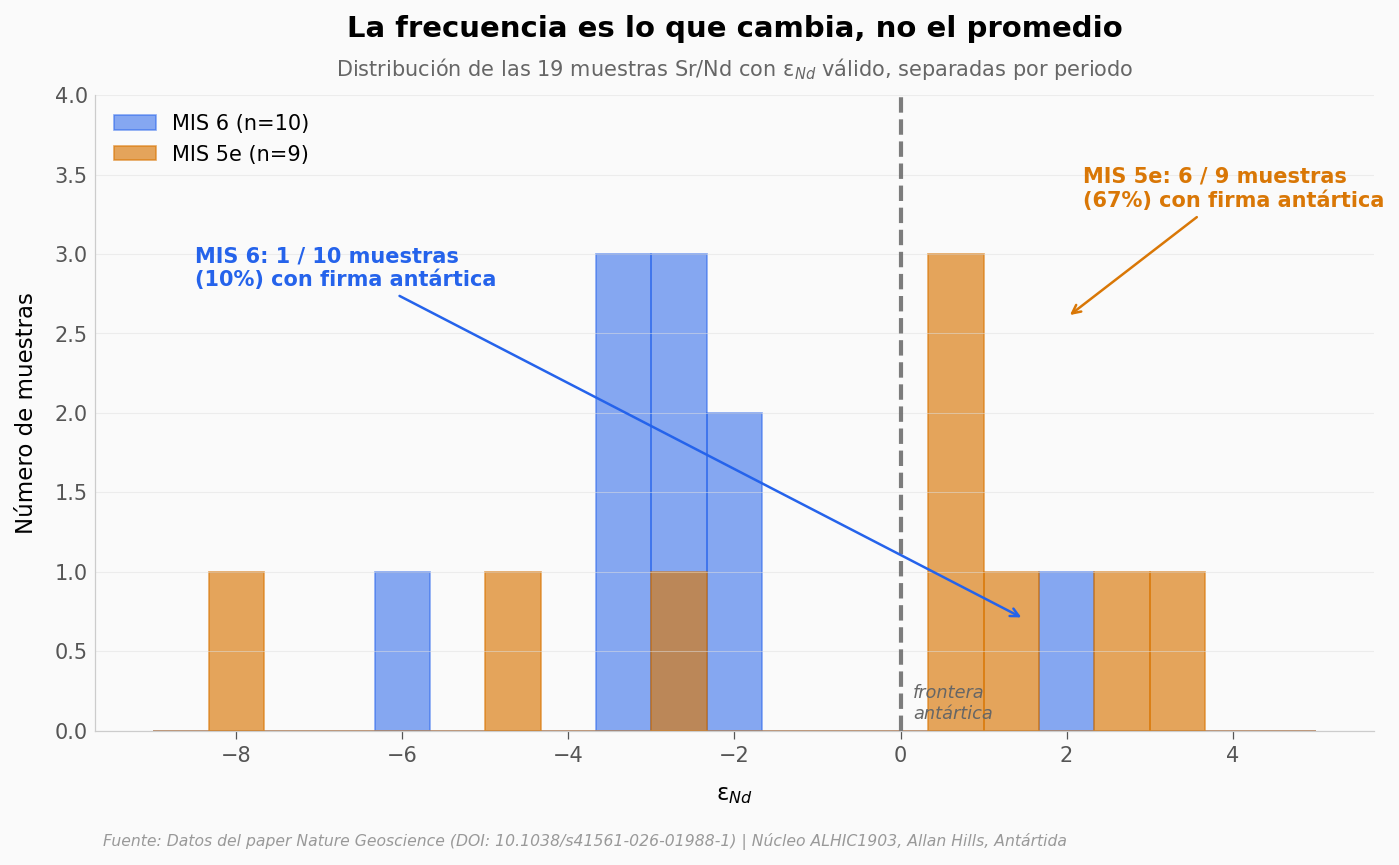

Shapiro p MIS 5e: 0.269 | MIS 6: 0.063 (>0,05 = compatible con normalidad)
Mann-Whitney U (diferencia de medias, no asume normalidad): p = 0.178   → no significativa al 0,05
Cohen's d (tamaño del efecto, en desviaciones estándar): +0.68   →   medio

Lectura: el cambio de medias por sí solo no llega a 'estadísticamente
significativo', pero el reparto entre muestras antárticas y sudamericanas
sí cambia mucho (67% vs 10%). El paper se apoya en la frecuencia, no en
la diferencia de medias.


In [5]:
# ══════════════════════════════════════════════════════════════
# Distribución de εNd por periodo + frontera "firma antártica"
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5.5))

mis5_vals = srnd[srnd["mis"] == "MIS 5e"]["epsilon_nd"].dropna().values
mis6_vals = srnd[srnd["mis"] == "MIS 6"]["epsilon_nd"].dropna().values

bins = np.linspace(-9, 5, 22)
ax.hist(mis6_vals, bins=bins, color=COLOR_MIS6, alpha=0.55,
        edgecolor=COLOR_MIS6, linewidth=0.8,
        label=f"MIS 6 (n={len(mis6_vals)})")
ax.hist(mis5_vals, bins=bins, color=COLOR_MIS5E, alpha=0.65,
        edgecolor=COLOR_MIS5E, linewidth=0.8,
        label=f"MIS 5e (n={len(mis5_vals)})")

# Línea vertical en eps_nd = 0 (firma antártica)
ax.axvline(x=UMBRAL_FIRMA_ANTARTICA, color="#666666",
           linewidth=2.0, linestyle="--", alpha=0.85)

# Anotar fracciones
frac_mis5 = (mis5_vals > 0).sum() / len(mis5_vals)
frac_mis6 = (mis6_vals > 0).sum() / len(mis6_vals)
ax.annotate(
    f"MIS 5e: {(mis5_vals>0).sum()} / {len(mis5_vals)} muestras\n"
    f"({100*frac_mis5:.0f}%) con firma antártica",
    xy=(2.0, 2.6), xytext=(2.2, 3.3),
    fontsize=10, color=COLOR_MIS5E, fontweight="bold", ha="left",
    arrowprops=dict(arrowstyle="->", color=COLOR_MIS5E, lw=1.2),
)
ax.annotate(
    f"MIS 6: {(mis6_vals>0).sum()} / {len(mis6_vals)} muestras\n"
    f"({100*frac_mis6:.0f}%) con firma antártica",
    xy=(1.5, 0.7), xytext=(-8.5, 2.8),
    fontsize=10, color=COLOR_MIS6, fontweight="bold", ha="left",
    arrowprops=dict(arrowstyle="->", color=COLOR_MIS6, lw=1.2),
)
ax.text(UMBRAL_FIRMA_ANTARTICA + 0.15, 0.05, "frontera\nantártica",
        fontsize=8.5, color="#666666", style="italic", va="bottom")

ax.set_xlabel("ε$_{Nd}$", fontsize=11)
ax.set_ylabel("Número de muestras", fontsize=11)
ax.set_title("La frecuencia es lo que cambia, no el promedio",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Distribución de las 19 muestras Sr/Nd con ε$_{Nd}$ válido, separadas por periodo",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.legend(fontsize=10, loc="upper left", framealpha=0.92)
ax.set_ylim(0, max(ax.get_ylim()[1], 4.0))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/distribucion_epsnd_por_periodo.png", dpi=200, bbox_inches="tight")
plt.show()

# Test estadístico (Mann-Whitney por no asumir normalidad con n bajo)
sh5 = stats.shapiro(mis5_vals).pvalue if len(mis5_vals) >= 3 else None
sh6 = stats.shapiro(mis6_vals).pvalue if len(mis6_vals) >= 3 else None
U, p_mw = stats.mannwhitneyu(mis5_vals, mis6_vals, alternative="two-sided")
pooled_std = np.sqrt(
    ((len(mis5_vals)-1)*mis5_vals.std(ddof=1)**2 +
     (len(mis6_vals)-1)*mis6_vals.std(ddof=1)**2) /
    (len(mis5_vals)+len(mis6_vals)-2)
)
cohen_d = (mis5_vals.mean() - mis6_vals.mean()) / pooled_std

print(f"Shapiro p MIS 5e: {sh5:.3f} | MIS 6: {sh6:.3f} "
      f"(>0,05 = compatible con normalidad)")
print(f"Mann-Whitney U (diferencia de medias, no asume normalidad): p = {p_mw:.3f}"
      f"   → {'no' if p_mw > 0.05 else 'sí'} significativa al 0,05")
print(f"Cohen's d (tamaño del efecto, en desviaciones estándar): {cohen_d:+.2f}"
      f"   →   {'pequeño' if abs(cohen_d)<0.5 else 'medio' if abs(cohen_d)<0.8 else 'grande'}")
print()
print("Lectura: el cambio de medias por sí solo no llega a 'estadísticamente")
print("significativo', pero el reparto entre muestras antárticas y sudamericanas")
print("sí cambia mucho (67% vs 10%). El paper se apoya en la frecuencia, no en")
print("la diferencia de medias.")

### Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| El polvo de MIS 6 viene principalmente de Sudamérica | ✅ | 8/10 muestras MIS 6 con ε$_{Nd}$ ≤ -2, rango típico de Sudamérica. Cohen's d = +0,68 (medio) entre periodos. |
| En MIS 5e aparece una fuente volcánica antártica local (sector McMurdo / West Antarctic Rift) | ✅ | 6/9 muestras MIS 5e (67%) con ε$_{Nd}$ > 0, compatible con Erebus (volcán activo antártico, +5,2), Marie Byrd Land (+4,8) y McMurdo Sound (+3,1). En MIS 6 esa firma aparece en 1/10 (10%). |
| El cambio de fuente dominante es la base del argumento, no la diferencia de medias | ⚠️ | Mann-Whitney entre medias da p = 0,18 — **no significativa al 0,05**. El paper lo enmarca como cambio de fuente dominante, no como diff de medias. |
| MIS 5e fue más cálido | ✅ | δD ~35‰ más positivo en MIS 5e vs MIS 6 (consistente con interglacial vs glacial). |
| Hubo más polvo en MIS 6 | ✅ | 3× más polvo en MIS 6 (306 ng/g medio, pico 1.009 ng/g) que en MIS 5e (101 ng/g medio). p = 0,046. |
| El Ross Ice Shelf colapsó y la Antártida occidental perdió hielo durante MIS 5e | ⚠️ | El paper lo enmarca como inferencia (*suggests*) basada en el cambio de fuente del polvo + simulaciones de modelo climático. NO es medición directa de pérdida de hielo. |
| Nivel del mar 5-10 m más alto en MIS 5e | — | Dato citado del paper original — proviene de otros estudios (Dutton, Kopp), no de los datos isotópicos de este núcleo. |

> **Limitaciones de los datos abiertos:**
> - **n = 22 muestras Sr/Nd** (11 por periodo en bruto; 9-10 con ε$_{Nd}$ válido). El argumento del paper se apoya en la mezcla de evidencias (isótopos + modelos + frecuencia de firmas), no en una sola comparación.
> - La frontera ε$_{Nd}$ = 0 para separar "firma antártica" es la convención del paper — fuentes con ε$_{Nd}$ ligeramente negativo también pueden ser antárticas (Dry Valleys, Northern Victoria Land).
> - El componente de modelo climático del paper (que estima cuánto cambia el viento si el Ross se abre) no está en estos datos — vive en las simulaciones del paper original.

## Ahora tú

¿Cuánto pesa cada PSA volcánica antártica frente a las muestras MIS 5e? Pista: filtra `psa` por las regiones volcánicas (`Erebus`, `Marie Byrd Land`, `McMurdo Sound`), calcula media de ε$_{Nd}$ y compárala con la media de las muestras MIS 5e.

¿Qué pasa si mueves la frontera entre periodos? Cambia `UMBRAL_TERMINATION_II_KA` en la celda 2 (por ejemplo a 128 o 130 ka) y re-ejecuta. ¿Cambian las fracciones 67% / 10%?

¿Hay alguna correlación entre concentración de polvo y firma isotópica? Pista: cruza `srnd` y `dust` por `age_ka` cercano (usa `pd.merge_asof`) y mira si las muestras más polvorosas son las que tienen ε$_{Nd}$ más negativo (sudamericano) o más positivo (antártico).

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1 resuelta: ¿cuán cerca cae cada PSA volcánica antártica
# de las muestras MIS 5e?

regiones_volcanicas = ["Erebus", "Marie Byrd Land", "McMurdo Sound"]
psa_volc = psa[psa["potential_source_area"].isin(regiones_volcanicas)]

resumen_psa = psa_volc.groupby("potential_source_area").agg(
    n=("epsilon_nd", "count"),
    eps_nd_media=("epsilon_nd", "mean"),
    sr_media=("sr87_sr86", "mean"),
).round(3)

media_mis5e = srnd[srnd["mis"] == "MIS 5e"]["epsilon_nd"].mean()
media_mis6  = srnd[srnd["mis"] == "MIS 6"]["epsilon_nd"].mean()

print(resumen_psa)
print()
print(f"ε_Nd medio de las muestras MIS 5e del núcleo: {media_mis5e:+.2f}")
print(f"ε_Nd medio de las muestras MIS 6 del núcleo:  {media_mis6:+.2f}")
print()
print("McMurdo Sound (+3,1) es la fuente más compatible — coincide con")
print("la zona que el paper señala explícitamente como origen probable.")

                        n  eps_nd_media  sr_media
potential_source_area                            
Erebus                 46         5.230     0.703
Marie Byrd Land        29         4.767     0.703
McMurdo Sound          17         3.073     0.705

ε_Nd medio de las muestras MIS 5e del núcleo: -0.61
ε_Nd medio de las muestras MIS 6 del núcleo:  -2.58

McMurdo Sound (+3,1) es la fuente más compatible — coincide con
la zona que el paper señala explícitamente como origen probable.


---

## Fuentes

**Paper**: [Diminished Ross Ice Shelf and West Antarctic Ice Sheet during Last Interglacial warming](https://doi.org/10.1038/s41561-026-01988-1)  
*Nature Geoscience, 2026-05-26*

**Source Data**: [Supplementary Source Data MOESM2 — δD, d-excess, dust concentration, dust flux, Sr/Nd isotopes del núcleo ALHIC1903 y registros de referencia (EPICA Dome C, TALDICE)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41561-026-01988-1/MediaObjects/41561_2026_1988_MOESM2_ESM.xlsx)

**Source Data**: [Supplementary Source Data MOESM3 — Base de datos compilada de Sr/Nd de 381 Potential Source Areas (PSAs) globales](https://static-content.springer.com/esm/art%3A10.1038%2Fs41561-026-01988-1/MediaObjects/41561_2026_1988_MOESM3_ESM.xlsx)

**Referencias citadas (datasets equivalentes en USAP-DC)**:
- [Allan Hills ALHIC1903 — dust mass concentration and dust flux (MIS 6 - MIS 5e)](https://doi.org/10.15784/602034)
- [Allan Hills ALHIC1903 — Sr and Nd isotope composition of dust](https://doi.org/10.15784/602031)
- [Allan Hills ALHIC1903 — rare earth element concentrations](https://doi.org/10.15784/602032)
- [Allan Hills ALHIC1903 — oxygen and hydrogen isotope composition of ice](https://doi.org/10.15784/602033)
- [Allan Hills ALHIC1903 — grain size distributions of dust](https://doi.org/10.15784/602045)

*16 afirmaciones del notebook verificadas contra estas fuentes*

**Notebook reproducible:** [GitHub — Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-26-ross-ice-shelf-mis-5e)

**Licencia datos:** los datos provienen del Supplementary Material del paper en Nature Geoscience (publicación abierta de los Source Data). PSA database: compilación referenciada en el paper.

**Cómo citar este notebook:** Ciencia a Mordiscos — El Lab (2026). *Reproducción isotópica del núcleo ALHIC1903 — Ross Ice Shelf en MIS 5e.* Análisis derivado del paper bajo DOI [10.1038/s41561-026-01988-1](https://doi.org/10.1038/s41561-026-01988-1).